In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA


display(Markdown("### Loading the Datasets"))

orders = pd.read_csv('C:/Users/cis101/Downloads/orders.csv')
prod_prior = pd.read_csv('C:/Users/cis101/Downloads/order_products__prior.csv')
prod_train = pd.read_csv('C:/Users/cis101/Downloads/order_products__train.csv')
products = pd.read_csv('C:/Users/cis101/Downloads/products.csv')

prod_all = pd.concat([prod_prior, prod_train], ignore_index=True)

display(orders.head())
display(prod_train.head())
display(products.head())

orders_num = ["order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]
train_num = ["add_to_cart_order", "reordered"]

display(orders[orders_num].describe())
display(prod_train[train_num].describe())

### Loading the Datasets

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


,add_to_cart_order,reordered
count,1.384617e+06,1.384617e+06
mean,8.758044e+00,5.985944e-01
std,7.423936e+00,4.901829e-01
min,1.000000e+00,0.000000e+00
25%,3.000000e+00,0.000000e+00
50%,7.000000e+00,1.000000e+00
75%,1.200000e+01,1.000000e+00
max,8.000000e+01,1.000000e+00


In [2]:
display(Markdown("### Data Preprocessing"))

print(orders.isnull().sum())

#Filling missing time since previous orders with 0 to cover first time purchases
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

#IQR clipping to remove outliers
def clip_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return s.clip(q1 - 1.5*iqr, q3 + 1.5*iqr)

orders["days_since_prior_order"] = clip_iqr(orders["days_since_prior_order"])
prod_train["add_to_cart_order"] = clip_iqr(prod_train["add_to_cart_order"])

print(orders.isnull().sum())

### Data Preprocessing

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


### Histograms

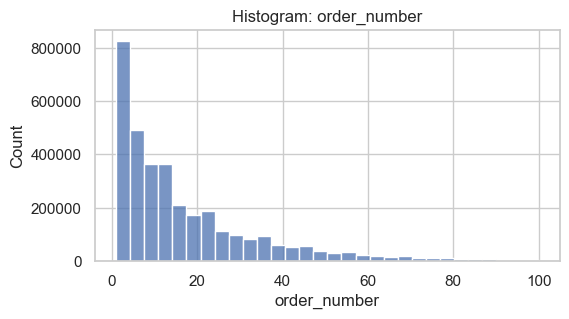

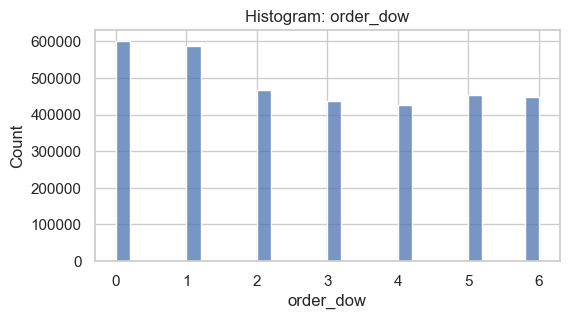

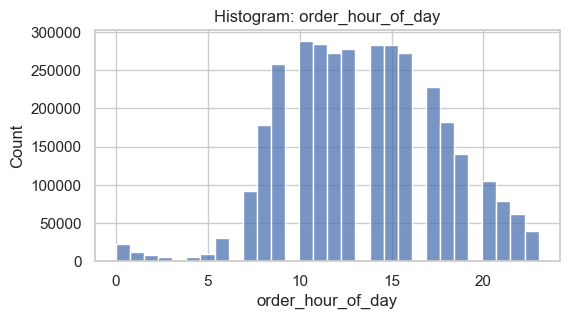

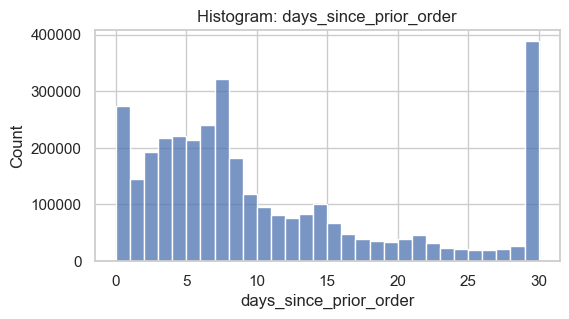

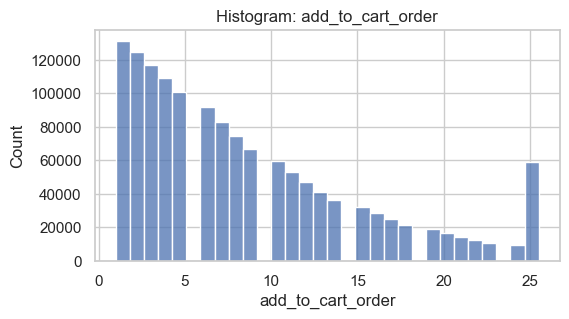

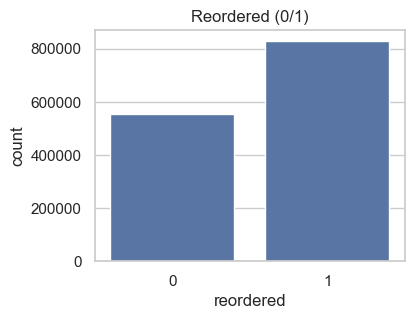

In [3]:
display(Markdown("### Histograms"))

sns.set(style="whitegrid")

for col in orders_num:
    plt.figure(figsize=(6,3))
    sns.histplot(orders[col], bins=30)
    plt.title(f"Histogram: {col}")
    plt.show()

plt.figure(figsize=(6,3))
sns.histplot(prod_train["add_to_cart_order"], bins=30)
plt.title("Histogram: add_to_cart_order")
plt.show()

plt.figure(figsize=(4,3))
sns.countplot(x=prod_train["reordered"])
plt.title("Reordered (0/1)")
plt.show()

### Boxplots

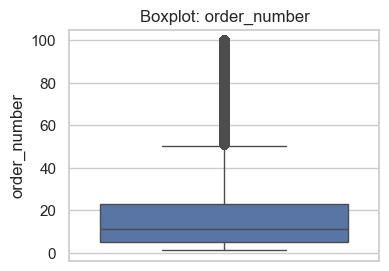

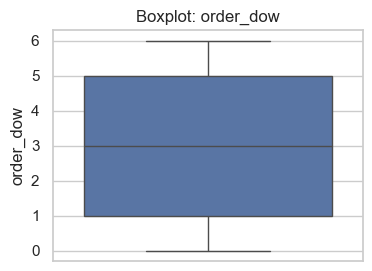

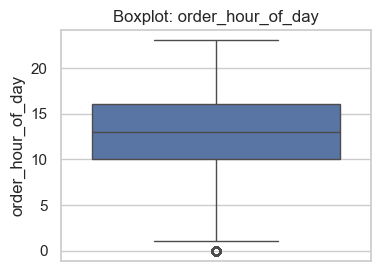

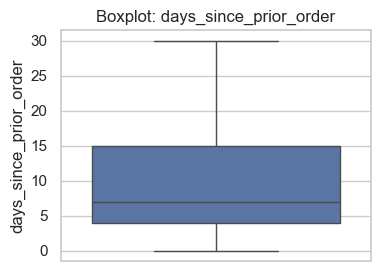

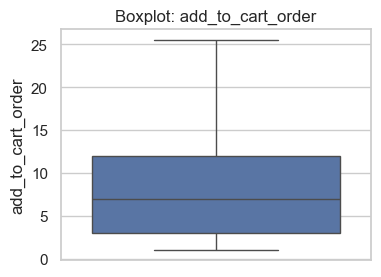

In [4]:
display(Markdown("### Boxplots"))

for col in orders_num:
    plt.figure(figsize=(4,3))
    sns.boxplot(y=orders[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

plt.figure(figsize=(4,3))
sns.boxplot(y=prod_train["add_to_cart_order"])
plt.title("Boxplot: add_to_cart_order")
plt.show()

In [5]:
display(Markdown("### Order-Level Features"))

order_stats = prod_all.groupby("order_id").agg(
    basket_size=("product_id", "count"),
    reorder_ratio=("reordered", "mean")).reset_index()

order_level = orders.merge(order_stats, on="order_id", how="left")

display(order_level.head())

### Order-Level Features

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,reorder_ratio
0,2539329,1,prior,1,2,8,0.0,5.0,0.000
1,2398795,1,prior,2,3,7,15.0,6.0,0.500
2,473747,1,prior,3,3,12,21.0,5.0,0.600
3,2254736,1,prior,4,4,7,29.0,5.0,1.000
4,431534,1,prior,5,4,15,28.0,8.0,0.625


### Correlation and Multivariate Analysis

,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,reorder_ratio
order_number,1.000000,0.015258,-0.035690,-0.270806,-0.002118,0.427285
order_dow,0.015258,1.000000,0.005978,-0.025322,-0.025404,-0.009876
order_hour_of_day,-0.035690,0.005978,1.000000,-0.001773,-0.005596,-0.032296
days_since_prior_order,-0.270806,-0.025322,-0.001773,1.000000,0.053734,-0.031366
basket_size,-0.002118,-0.025404,-0.005596,0.053734,1.000000,-0.034818
reorder_ratio,0.427285,-0.009876,-0.032296,-0.031366,-0.034818,1.000000


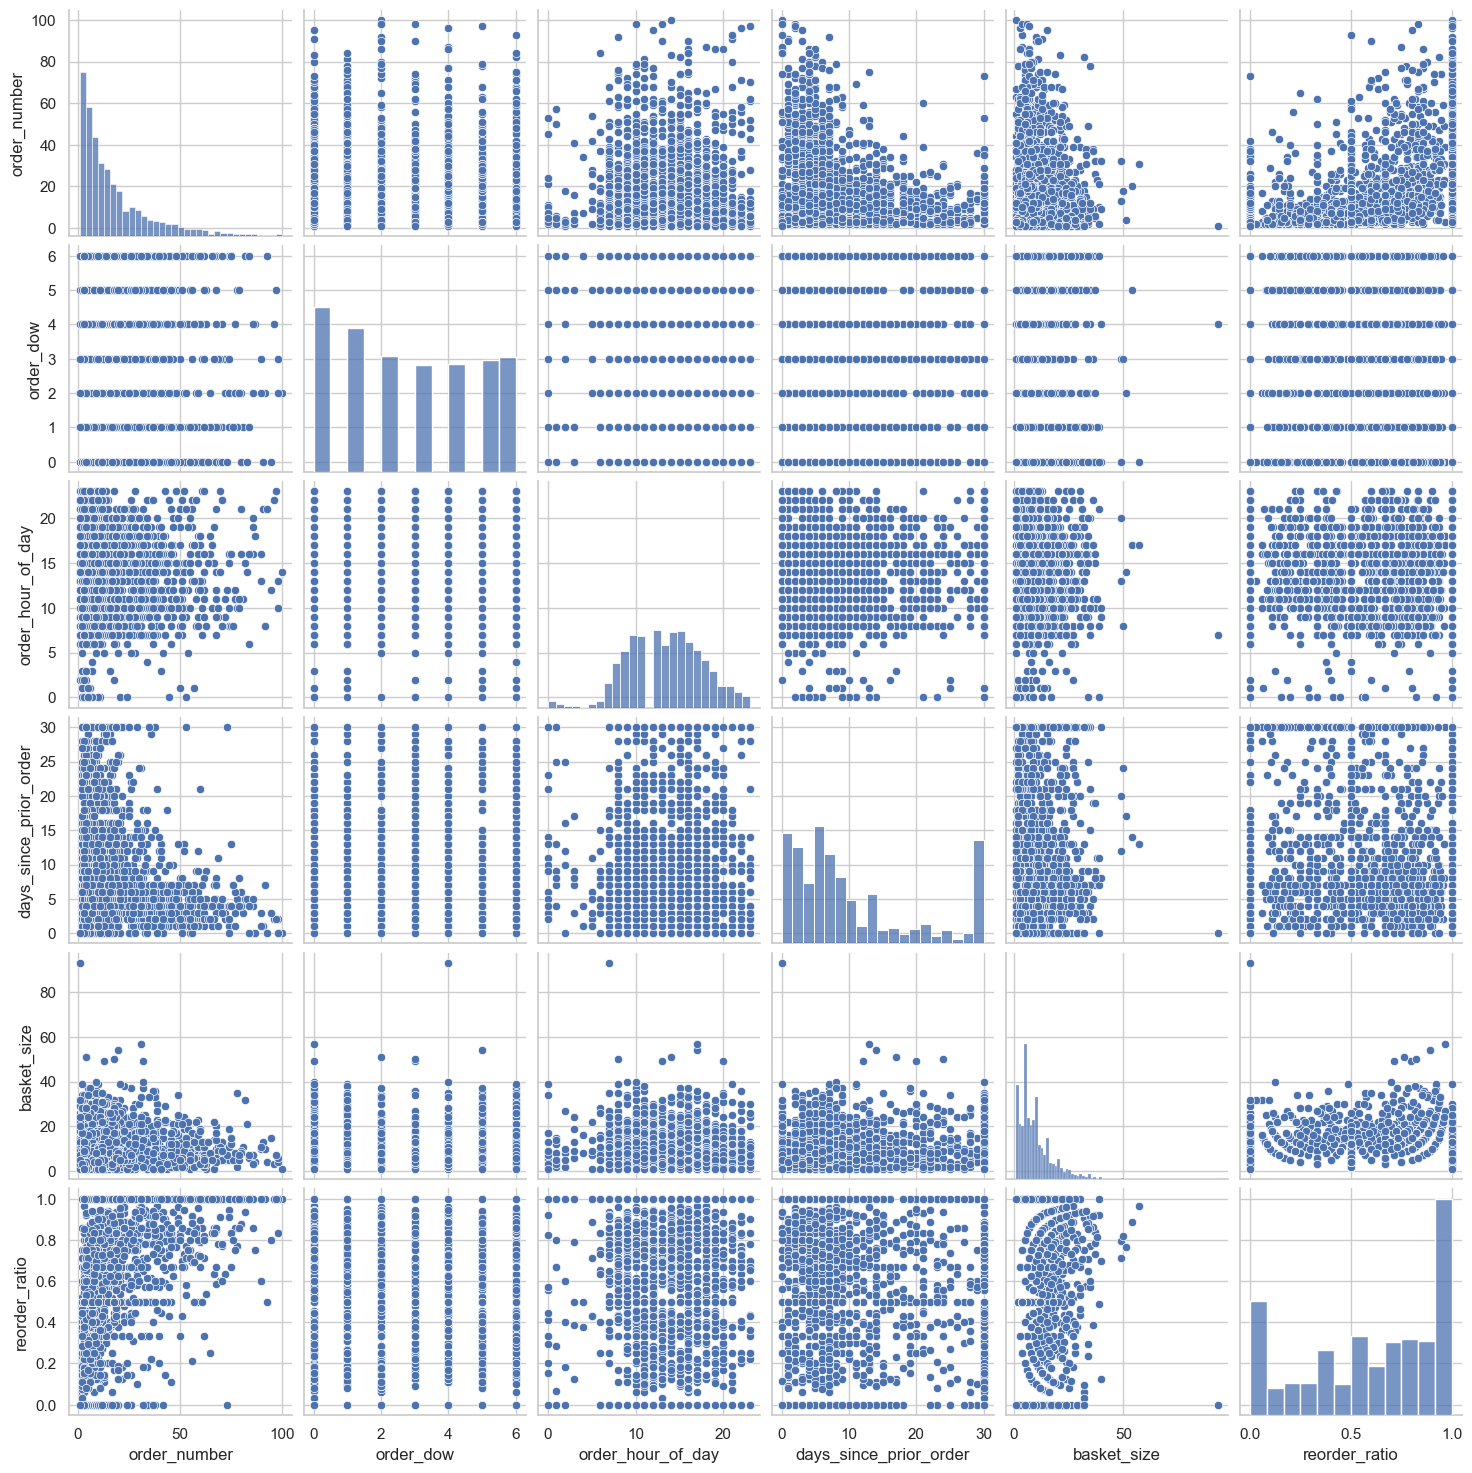

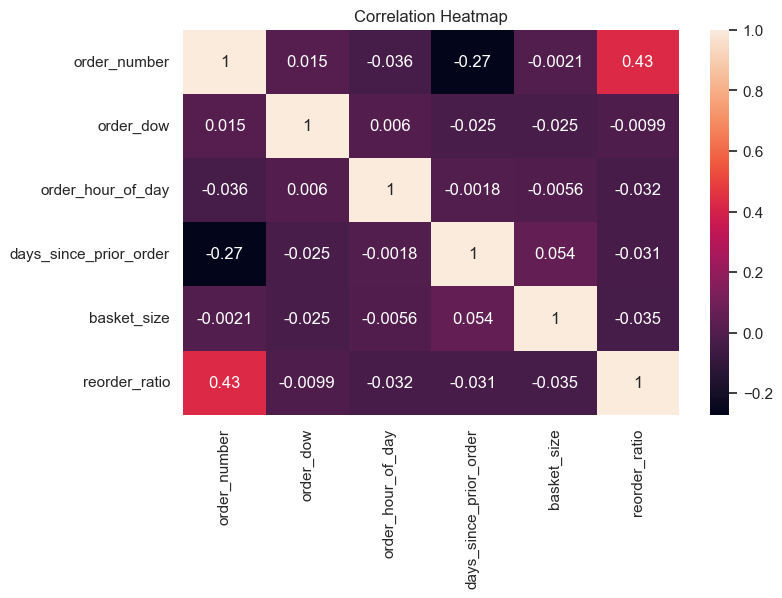

In [6]:
display(Markdown("### Correlation and Multivariate Analysis"))

num_cols = ["order_number", "order_dow", "order_hour_of_day",
            "days_since_prior_order", "basket_size", "reorder_ratio"]

corr = order_level[num_cols].corr()
display(corr)

# sampled pair plot
sample = order_level[num_cols].dropna().sample(
    n=min(2000, len(order_level)), random_state=42)

sns.pairplot(sample)
plt.show()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Reorder Timing Analysis

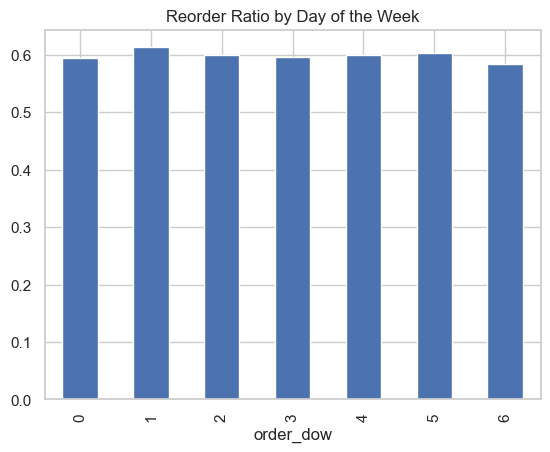

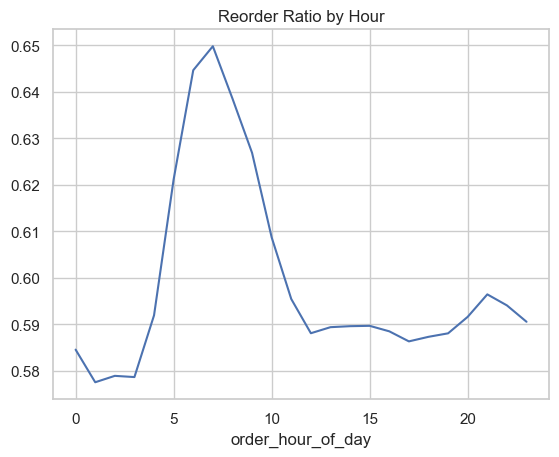

C:\Users\cis101\AppData\Local\Temp\ipykernel_7624\3838555540.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_level.groupby("days_bin")["reorder_ratio"].mean().plot(kind="bar")


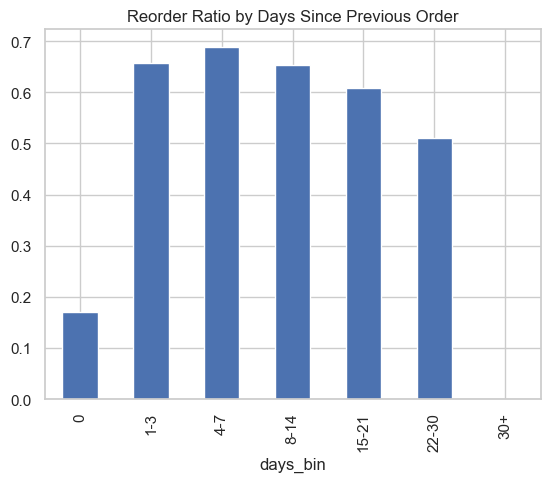

In [7]:
display(Markdown("Reorder Timing Analysis"))

order_level.groupby("order_dow")["reorder_ratio"].mean().plot(kind="bar")
plt.title("Reorder Ratio by Day of the Week")
plt.show()

order_level.groupby("order_hour_of_day")["reorder_ratio"].mean().plot()
plt.title("Reorder Ratio by Hour")
plt.show()

order_level["days_bin"] = pd.cut(
    order_level["days_since_prior_order"],
    bins=[-0.1, 0, 3, 7, 14, 21, 30, 1000],
    labels=["0", "1-3", "4-7", "8-14", "15-21", "22-30", "30+"])

order_level.groupby("days_bin")["reorder_ratio"].mean().plot(kind="bar")
plt.title("Reorder Ratio by Days Since Previous Order")
plt.show()

In [8]:
from itertools import combinations

display(Markdown("### Analysis on Market Basket"))

sample_orders = prod_all["order_id"].drop_duplicates().sample(5000, random_state=42)
prod_sample = prod_all[prod_all["order_id"].isin(sample_orders)][["order_id", "product_id"]]

num_orders = prod_sample["order_id"].nunique()
product_counts = prod_sample["product_id"].value_counts()

pair_counts = {}
for _, grp in prod_sample.groupby("order_id"):
    items = sorted(grp["product_id"].unique())
    for a,b in combinations(items,2):
        pair_counts[(a,b)] = pair_counts.get((a,b),0)+1

pairs_df = pd.DataFrame(
    [(a,b,c) for (a,b),c in pair_counts.items()],
    columns=["A", "B", "pair_count"]
)

pairs_df["support"] = pairs_df["pair_count"]/num_orders
pairs_df["confidence"] = pairs_df["pair_count"]/pairs_df["A"].map(product_counts)

display(pairs_df.sort_values("support", ascending=False).head(10))

### Analysis on Market Basket

,A,B,pair_count,support,confidence
3286,21137,24852,93,0.0186,0.227384
2005,13176,21137,91,0.0182,0.146302
2028,13176,47209,91,0.0182,0.146302
1450,13176,21903,88,0.0176,0.141479
4750,24852,47766,75,0.0150,0.106686
1352,21903,24852,68,0.0136,0.178947
3425,24852,47626,66,0.0132,0.093883
2012,13176,27966,65,0.0130,0.104502
2266,21137,21903,58,0.0116,0.141809
2289,21137,47209,58,0.0116,0.141809


In [9]:
display(Markdown("Additional Pre-processing"))

train_model = (
    prod_train.merge(orders, on="order_id").merge(products[["product_id", "aisle_id", "department_id"]],
                                                on="product_id"))
# Grouping together the numerical and categorical features
num_features = ["order_number", "order_hour_of_day",
                "days_since_prior_order", "add_to_cart_order"]

cat_features = ["order_dow", "aisle_id", "department_id"]

X = train_model[num_features + cat_features]
y = train_model["reordered"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preparing features by OneHotEncoding Categorical features and standardizing the Numerical Features
prep = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])

X_train_ready = prep.fit_transform(X_train)
X_test_ready = prep.transform(X_test)

# PCA to help with future training
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_ready.toarray())
X_test_pca = pca.transform(X_test_ready.toarray())

print("Final Test Shape:", X_train_pca.shape)

Additional Pre-processing

Final Test Shape: (1107693, 43)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

display(Markdown("### Logistic Regression Model"))

# train model
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train_ready, y_train)

# predictions
y_pred = base_model.predict(X_test_ready)

# evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Base Model Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Logistic Regression Model

Base Model Performance:
Accuracy: 0.6706677644407852
Precision: 0.6850679811171837
Recall: 0.8325581395348837
F1-Score: 0.751646161135892

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.43      0.51    111159
           1       0.69      0.83      0.75    165765

    accuracy                           0.67    276924
   macro avg       0.66      0.63      0.63    276924
weighted avg       0.66      0.67      0.66    276924



In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

display(Markdown("Implementing Neural Network"))

X_train_dense = X_train_ready.toarray()
X_test_dense = X_test_ready.toarray()

# Defining Model
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Training model
history = model.fit(
    X_train_dense, y_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_test_dense, y_test),
    verbose=1
)

Implementing Neural Network

C:\Users\cis101\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.6729 - loss: 0.6008 - val_accuracy: 0.6796 - val_loss: 0.5924
Epoch 2/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.6795 - loss: 0.5938 - val_accuracy: 0.6800 - val_loss: 0.5914
Epoch 3/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.6797 - loss: 0.5936 - val_accuracy: 0.6807 - val_loss: 0.5915
Epoch 4/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.6804 - loss: 0.5927 - val_accuracy: 0.6805 - val_loss: 0.5909
Epoch 5/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.6808 - loss: 0.5923 - val_accuracy: 0.6807 - val_loss: 0.5911
Epoch 6/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.6822 - loss: 0.5908 - val_accuracy: 0.6804 - val_loss: 0.5913
Epoch 7/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.6816 - loss: 0.5912 - val_accuracy: 0.6811 - val_loss: 0.5905
Epoch 8/20
4327/4327 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.6830 - loss: 0

### Performance Analysis

8654/8654 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step 
Trained Model Performance:
Accuracy: 0.6823857809362858
Precision: 0.7006218995266138
Recall: 0.8196301993786385
F1-Score: 0.7554679485219093
Baseline Accuracy: 0.6706677644407852
Trained Accuracy: 0.6823857809362858


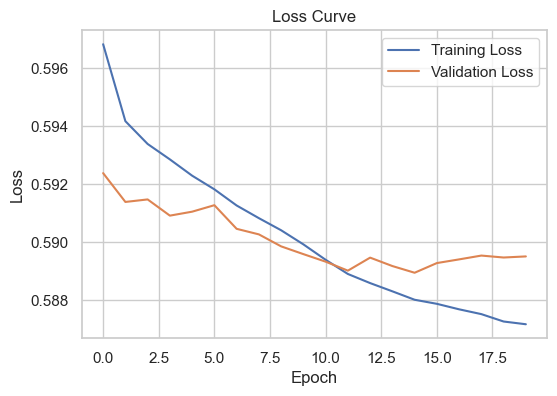

In [12]:
display(Markdown("### Performance Analysis"))

y_pred_new = (model.predict(X_test_dense) > 0.5).astype(int)

# evaluate performance
accuracy_new = accuracy_score(y_test, y_pred_new)
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)
f1_new = f1_score(y_test, y_pred_new)

print("Trained Model Performance:")
print("Accuracy:", accuracy_new)
print("Precision:", precision_new)
print("Recall:", recall_new)
print("F1-Score:", f1_new)

# Comparison
print("Baseline Accuracy:", accuracy)
print("Trained Accuracy:", accuracy_new)

#Plotting loss curve
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



Potential Areas that I could improve this is by adding dropout layers to help reduce overfitting, I could also use early stop to stop the training when the validation loss stops improving, and tuning hyperparameters

Scenario 1: simulating that customers are placing their orders on saturdays, which will test if customers reorder more on weekends.

Scenario 2: testing to see if changes to the time of day affects reorder behavior.

Scenario 3: testing to see if customers that wait longer are likely to reorder.

In [14]:
display(Markdown("### Scenario Analysis"))

X_test_scen = X_test.copy()

scenarios = {
    "Baseline": {},
    "Weekend (Saturday)": {"order_dow": 6},
    "Evening (10pm)": {"order_hour_of_day": 22},
    "Long Gap (30 days)": {"days_since_prior_order": 30}
}

scenario_results = []

for name, changes in scenarios.items():
    temp = X_test_scen.copy()

    for col, val in changes.items():
        temp[col] = val

    temp_ready = prep.transform(temp)
    temp_dense = temp_ready.toarray()

    probs = model.predict(temp_dense, verbose=0).reshape(-1)

    scenario_results.append({
        "Scenario": name,
        "Average_Predicted_Reorder_Probability": probs.mean()
    })

scenario_summary = pd.DataFrame(scenario_results)
display(scenario_summary)

scenario_summary.to_csv("scenario_summary.csv", index=False)

### Scenario Analysis

,Scenario,Average_Predicted_Reorder_Probability
0,Baseline,0.605384
1,Weekend (Saturday),0.603427
2,Evening (10pm),0.608221
3,Long Gap (30 days),0.544368


In [13]:
print("Exporting datasets for Power BI")

order_level_export = order_level[["order_id", "user_id", "order_number", 
                                  "order_dow", "order_hour_of_day", "days_since_prior_order",
                                  "reorder_ratio", "reorder_ratio"
]].copy()

order_level_export["days_bin"] = pd.cut(
    order_level_export["days_since_prior_order"],
    bins=[-0.1, 0, 3, 7, 14, 21, 30, 1000],
    labels=["0", "1-3", "4-7", "8-14", "15-21", "22-30", "30+"]
)

basket_stats = prod_all.groupby("order_id").agg(
    basket_size=("product_id", "count"),
)
order_level = orders.merge(basket_stats, on="order_id", how="left")
order_level_export.to_csv("order_level.csv", index=False)

pairs_df = pairs_df[pairs_df["pair_count"] >= 100]
pairs_export = pairs_df.copy()

pairs_export = pairs_export.merge(
    products[["product_id", "product_name"]].rename(columns={"product_id": "A", "product_name": "Product_A"}),
    on="A", how="left"
).merge(
    products[["product_id", "product_name"]].rename(columns={"product_id": "B", "product_name": "Product_B"}),
    on="B", how="left"
)

pairs_export = pairs_export.sort_values("support", ascending=False).head(200)
pairs_export.to_csv("basket_pairs.csv", index=False)

model_metrics = pd.DataFrame([
    {"Model": "Base Model Performance",
     "Accuracy": accuracy,
     "Precision": precision,
     "Recall": recall,
     "F1": f1},

    {"Model": "Trained Model Performance",
     "Accuracy": accuracy_new,
     "Precision": precision_new,
     "Recall": recall_new,
     "F1": f1_new}
])

model_metrics.to_csv("model_metrics.csv", index=False)

loss_list = history.history.get("loss", [])
val_loss_list = history.history.get("val_loss", [])

if len(loss_list)== 0:
    raise ValueError("No training loss found.")

if len(val_loss_list) == 0:
    loss_df = pd.DataFrame({
        "epoch": range(1, n + 1),
        "train_loss": loss_list[:n],
        "val_loss": val_loss_list[:n]
    })
else:
    n = min(len(loss_list), len(val_loss_list))
    loss_df = pd.DataFrame({
        "epoch": range(1, n + 1),
        "train_loss": loss_list[:n],
        "val_loss": val_loss_list[:n]
    })

loss_df.to_csv("loss_curve.csv", index=False)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_new)
cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"],
                     columns=["Pred_0", "Pred_1"])

cm_df.to_csv("confusion_matrix.csv")

Exporting datasets for Power BI
